# VQ-VAE on MNIST

Encoder -> continuous latents $z_e$ -> quantization via codebook -> decoder.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

torch.manual_seed(0)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
device


device(type='mps')

## Data

In [2]:
batch_size = 128
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
x, _ = next(iter(train_loader))
x.shape


100%|██████████| 9.91M/9.91M [00:01<00:00, 7.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 176kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.89MB/s]


torch.Size([128, 1, 28, 28])

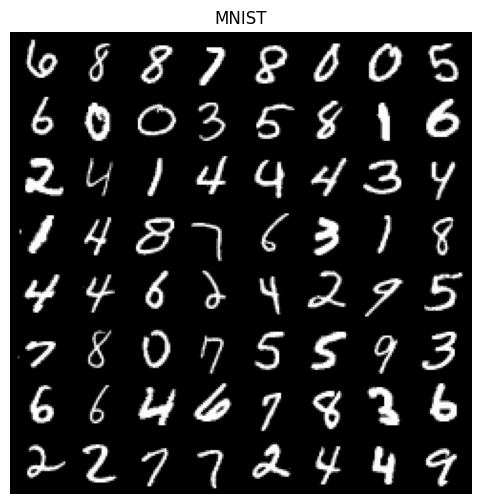

In [3]:
def show_batch(x, n=64, title=""):
    x = x[:n].detach().cpu()
    grid = make_grid(x, nrow=int(math.sqrt(n)))
    plt.figure(figsize=(6,6))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
    plt.show()

show_batch(x, title="MNIST")


## Vector quantizer

In [4]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings=256, embedding_dim=64, beta=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.beta = beta
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        nn.init.uniform_(self.embedding.weight, -1.0/num_embeddings, 1.0/num_embeddings)

    def forward(self, z_e):
        B, C, H, W = z_e.shape
        z = z_e.permute(0,2,3,1).contiguous().view(-1, C)  # (N,C)

        z_sq = (z**2).sum(dim=1, keepdim=True)                # (N,1)
        e_sq = (self.embedding.weight**2).sum(dim=1)          # (K,)
        ze = z @ self.embedding.weight.t()                    # (N,K)
        dist = z_sq + e_sq.unsqueeze(0) - 2*ze                # (N,K)

        indices = torch.argmin(dist, dim=1)                   # (N,)
        z_q = self.embedding(indices)                         # (N,C)

        z_q = z_q.view(B, H, W, C).permute(0,3,1,2).contiguous()
        indices = indices.view(B, H, W)

        codebook_loss = F.mse_loss(z_q, z_e.detach())
        commitment_loss = F.mse_loss(z_e, z_q.detach())
        loss_vq = codebook_loss + self.beta * commitment_loss

        z_q_st = z_e + (z_q - z_e).detach()  # straight-through
        return z_q_st, loss_vq, indices


## VQ-VAE model

In [5]:
class VQVAE(nn.Module):
    def __init__(self, hidden=64, code_dim=64, K=256, beta=0.25):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, hidden, 4, 2, 1),      # 14x14
            nn.ReLU(True),
            nn.Conv2d(hidden, hidden, 4, 2, 1), # 7x7
            nn.ReLU(True),
            nn.Conv2d(hidden, code_dim, 1),
        )
        self.vq = VectorQuantizer(num_embeddings=K, embedding_dim=code_dim, beta=beta)
        self.decoder = nn.Sequential(
            nn.Conv2d(code_dim, hidden, 3, 1, 1),
            nn.ReLU(True),
            nn.ConvTranspose2d(hidden, hidden, 4, 2, 1),  # 14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(hidden, 1, 4, 2, 1),       # 28x28
            nn.Sigmoid(),
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, loss_vq, indices = self.vq(z_e)
        xhat = self.decoder(z_q)
        return xhat, loss_vq, indices

vqvae = VQVAE(hidden=64, code_dim=64, K=256, beta=0.25).to(device)
sum(p.numel() for p in vqvae.parameters())


190785

## Train

Epoch 1/5:   0%|          | 0/468 [00:00<?, ?it/s]

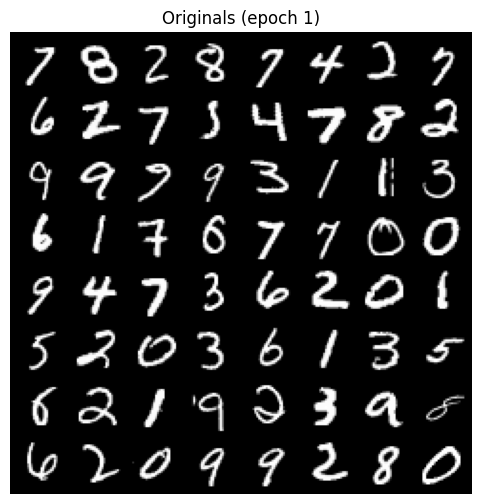

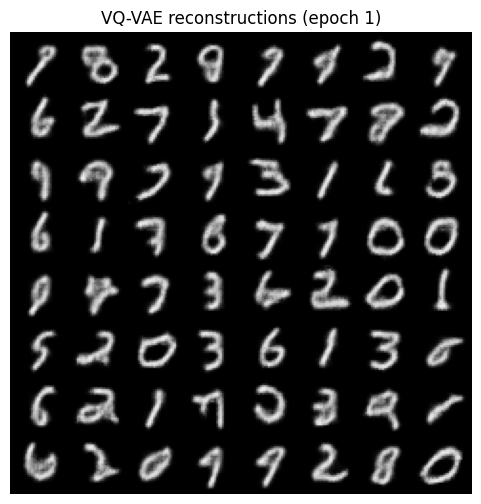

Epoch 2/5:   0%|          | 0/468 [00:00<?, ?it/s]

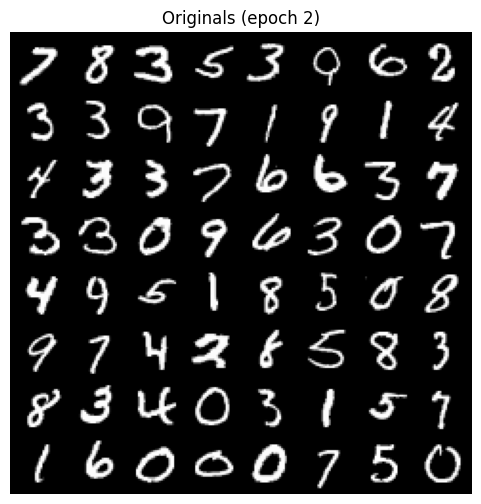

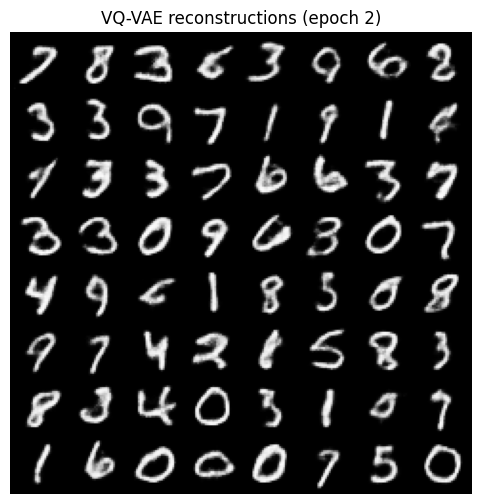

Epoch 3/5:   0%|          | 0/468 [00:00<?, ?it/s]

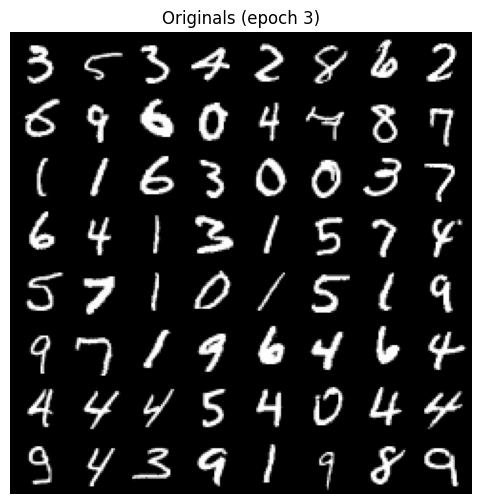

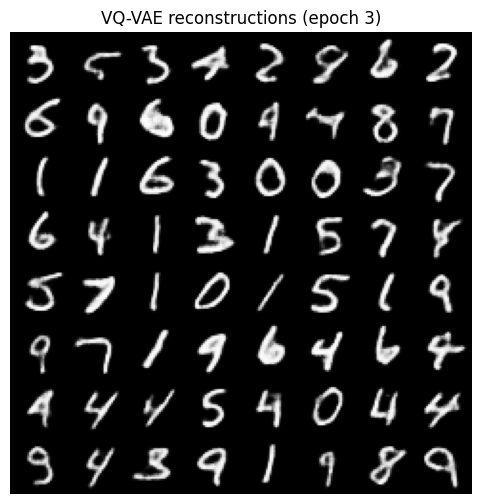

Epoch 4/5:   0%|          | 0/468 [00:00<?, ?it/s]

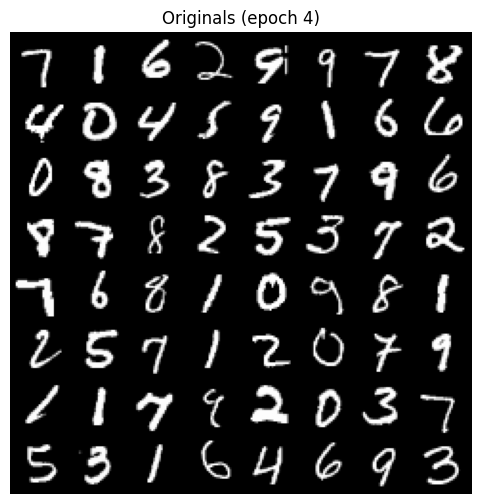

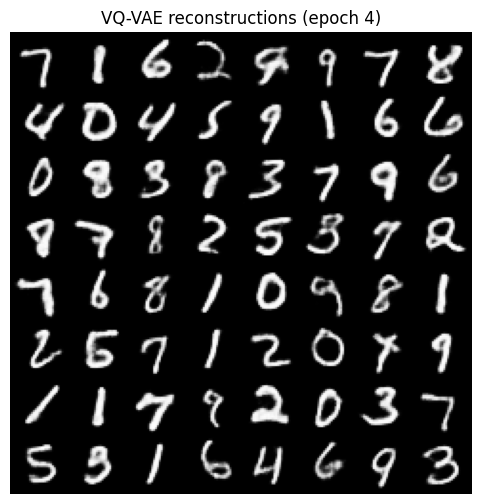

Epoch 5/5:   0%|          | 0/468 [00:00<?, ?it/s]

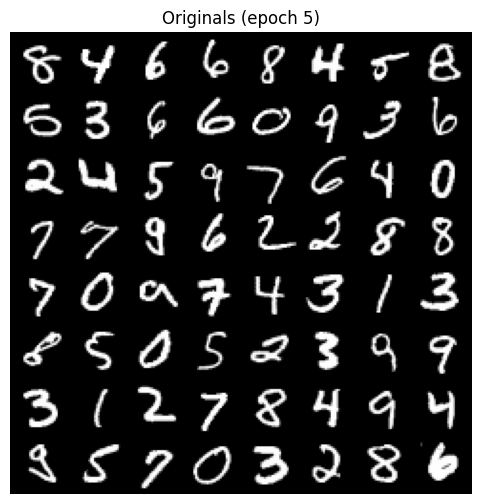

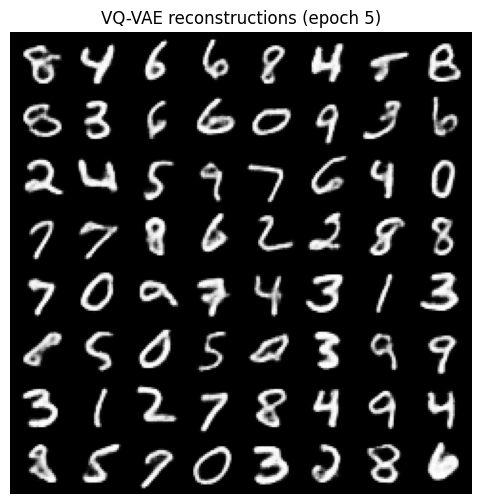

In [6]:
opt = torch.optim.Adam(vqvae.parameters(), lr=2e-3)
epochs = 5

vqvae.train()
for epoch in range(epochs):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for x, _ in pbar:
        x = x.to(device)
        xhat, loss_vq, _ = vqvae(x)
        recon = F.binary_cross_entropy(xhat, x, reduction="mean")
        loss = recon + loss_vq

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        pbar.set_postfix({"loss": f"{loss.item():.3f}", "recon": f"{recon.item():.3f}", "vq": f"{loss_vq.item():.3f}"})

    vqvae.eval()
    with torch.no_grad():
        x_vis = x[:64]
        xhat_vis, _, _ = vqvae(x_vis)
    show_batch(x_vis, title=f"Originals (epoch {epoch+1})")
    show_batch(xhat_vis, title=f"VQ-VAE reconstructions (epoch {epoch+1})")
    vqvae.train()


## Discrete indices

In [7]:
vqvae.eval()
with torch.no_grad():
    x_vis = next(iter(train_loader))[0][:16].to(device)
    _, _, idx = vqvae(x_vis)  # (B,7,7)
idx.shape, idx.min().item(), idx.max().item()


(torch.Size([16, 7, 7]), 17, 226)